Loaded: (230548, 35)
Columns: ['date', 'ticker', 'open', 'high', 'low', 'close', 'volume', 'MA_7', 'MA_21', 'MA_50', 'MA_200', 'EMA_12', 'EMA_26', 'MACD', 'MACD_signal', 'MACD_hist', 'RSI', 'BB_mid', 'BB_std', 'BB_upper', 'BB_lower', 'BB_width', 'BB_pos', 'momentum_5', 'momentum_10', 'momentum_21', 'volatility_21', 'volume_MA_10', 'volume_ratio', 'daily_return', 'hl_spread', 'close_vs_open', 'price_vs_MA50', 'price_vs_MA200', 'target']
Anomaly dataset shape: (230548, 10)

Running Isolation Forest...
Total records  : 230548
Anomalies found: 4611 (2.0%)

Volatility Spikes : 2306
Volume Spikes     : 2306
Extreme Crashes   : 1153
Extreme Surges    : 1153

=== TOP 20 ANOMALIES ===
      date     ticker   close  daily_return  volume_ratio  volatility_spike  volume_spike  extreme_crash  extreme_surge
2010-09-08  BRITANNIA  482.75     -0.772636      8.828834                 1             1              1              0
2011-06-23      TITAN  228.90     -0.946674      7.149636                 1

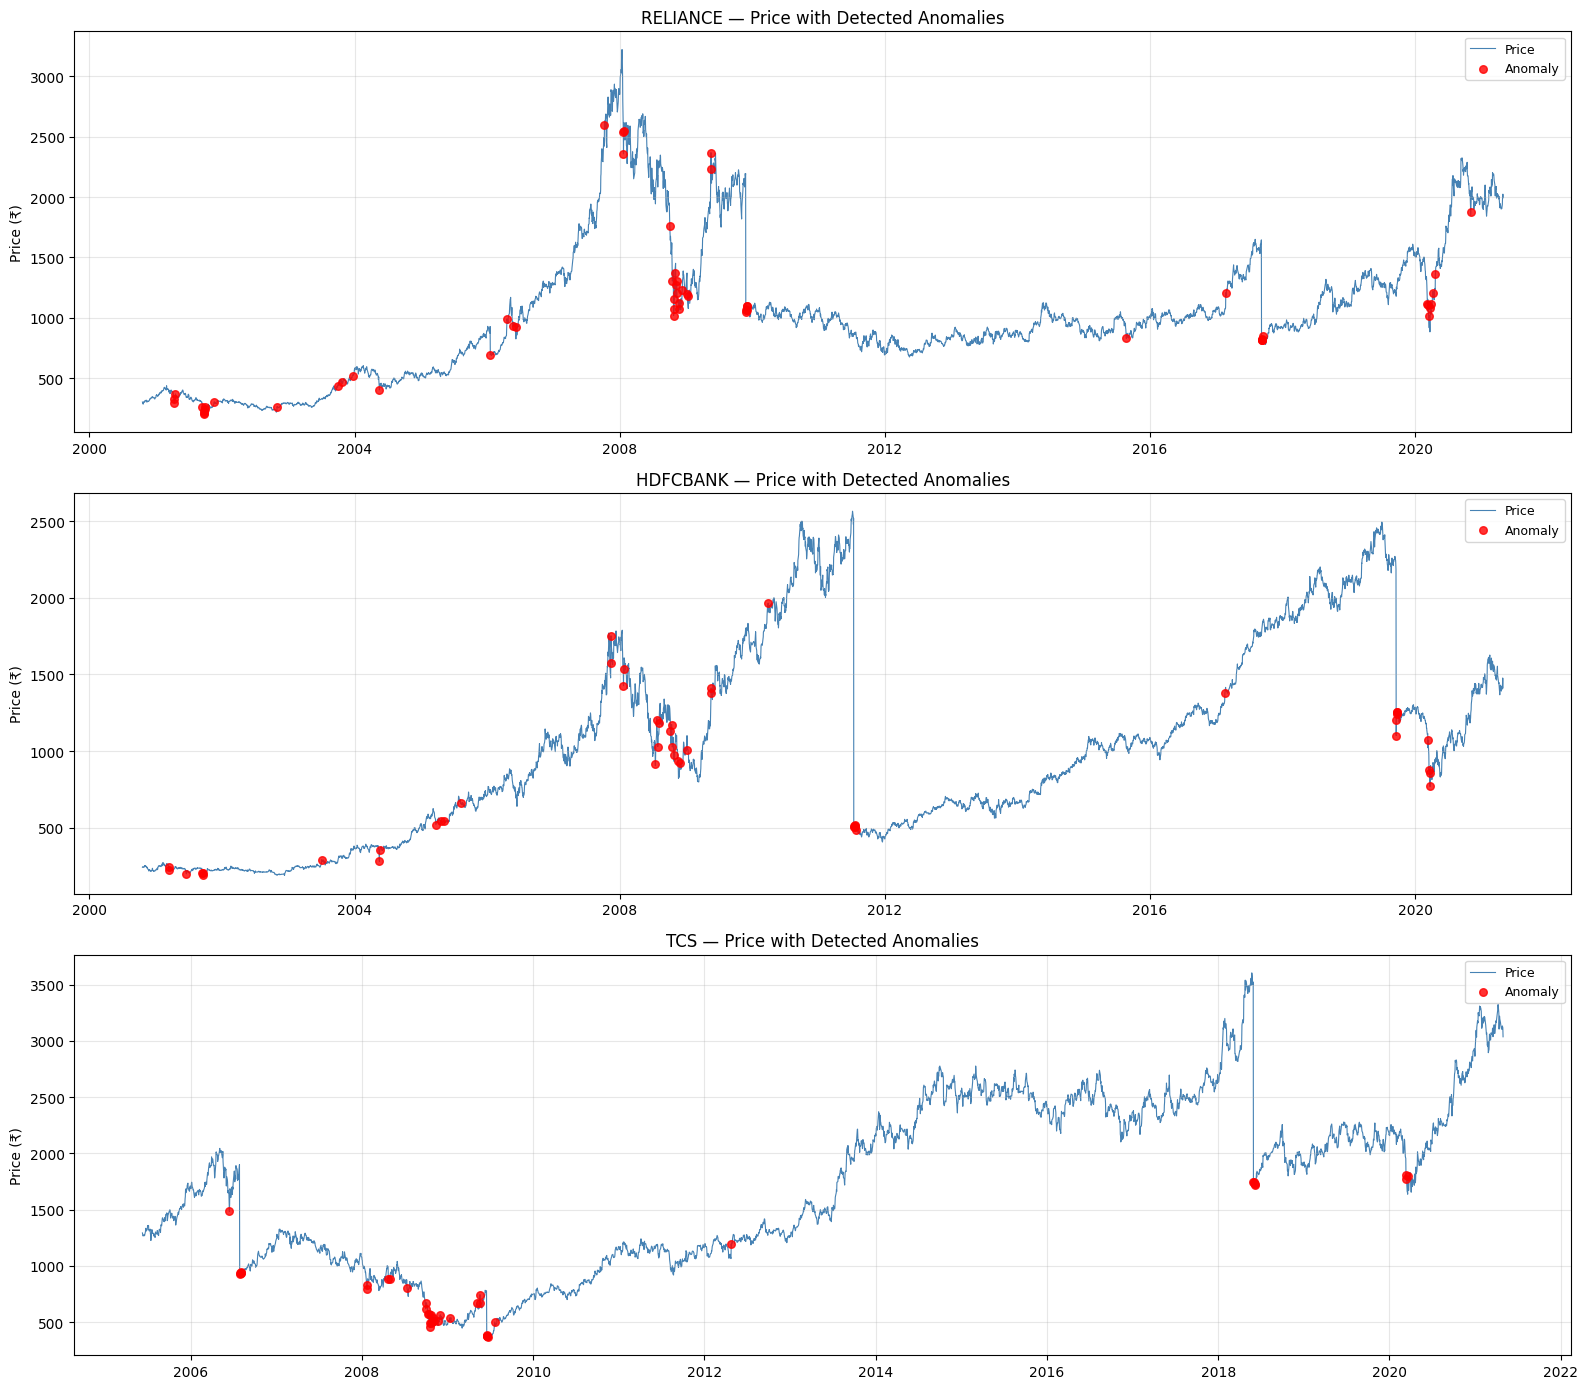

Anomaly price chart saved ✅


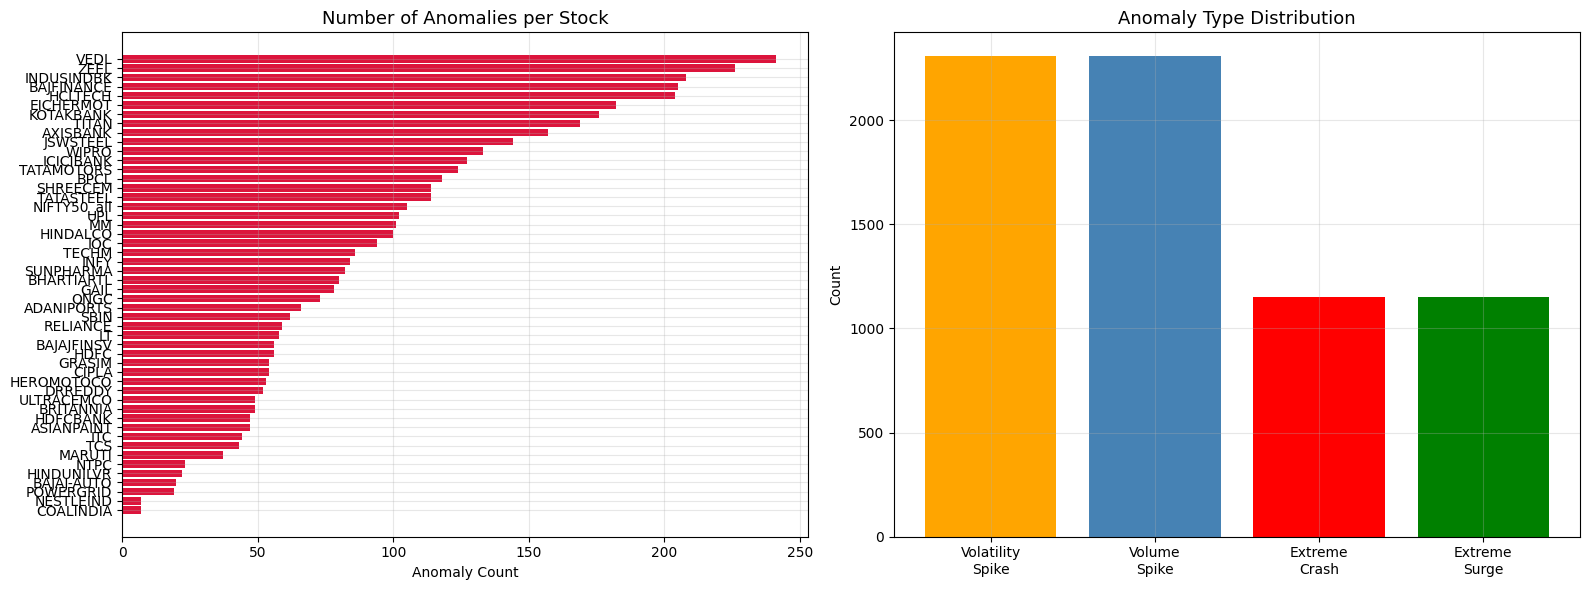

Anomaly type chart saved ✅


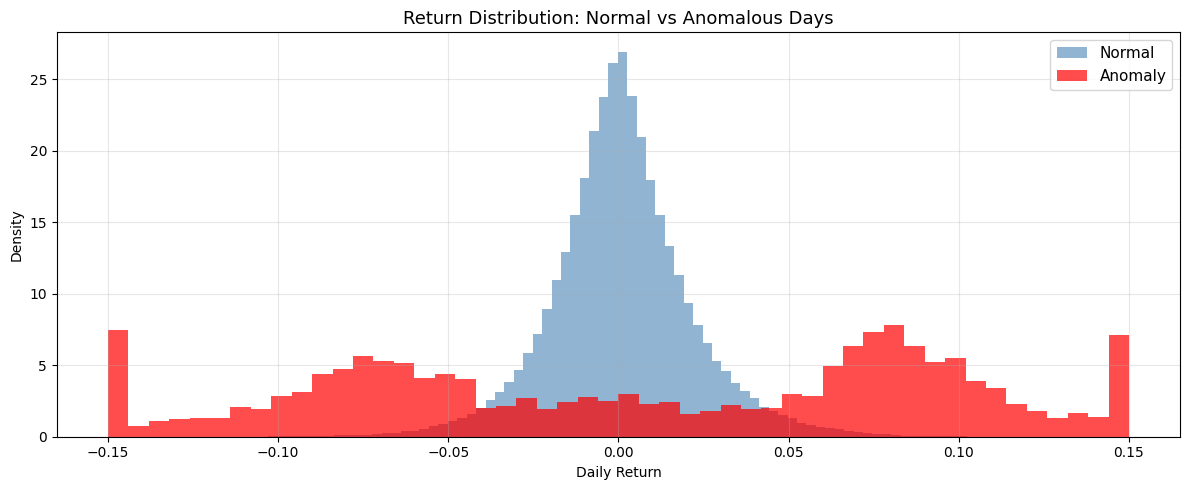

Return distribution chart saved ✅


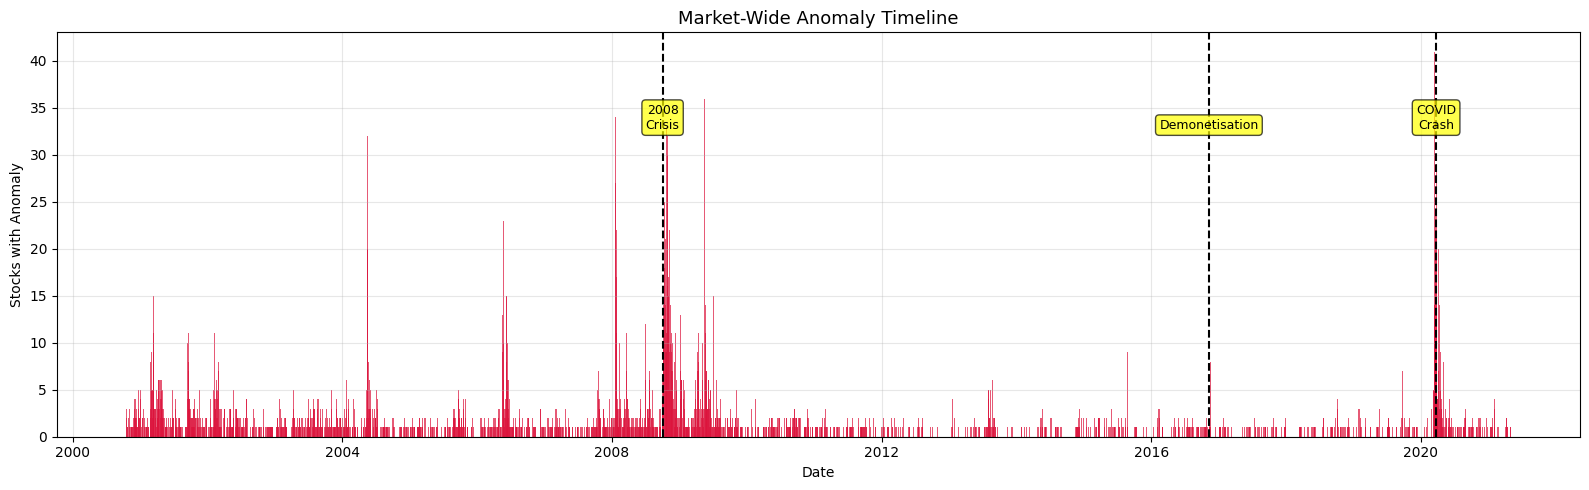

Timeline chart saved ✅

Anomaly data saved ✅
ANOMALY MODULE DONE ✅


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings, os
warnings.filterwarnings('ignore')

FEATURES_PATH = r"C:\Users\sarin\Downloads\nifty50_project\data\features_data.csv"
OUTPUT_FOLDER = r"C:\Users\sarin\Downloads\nifty50_project\outputs"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# ── LOAD ──────────────────────────────────────────────────────
df = pd.read_csv(FEATURES_PATH, parse_dates=['date'])
df = df.sort_values(['ticker','date']).reset_index(drop=True)

# ── FIX: Remove duplicate columns ─────────────────────────────
df = df.loc[:, ~df.columns.duplicated()]
print(f"Loaded: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# ── STEP 1: BUILD ANOMALY FEATURES ────────────────────────────
anomaly_features = ['daily_return', 'volume_ratio', 'hl_spread',
                    'volatility_21', 'momentum_5', 'close_vs_open']

df_anomaly = df[['date','ticker','close','volume','daily_return'] +
                anomaly_features].copy()

# Fix: drop duplicate columns again after selection
df_anomaly = df_anomaly.loc[:, ~df_anomaly.columns.duplicated()]
df_anomaly = df_anomaly.dropna()

print(f"Anomaly dataset shape: {df_anomaly.shape}")

# ── STEP 2: ISOLATION FOREST ──────────────────────────────────
print("\nRunning Isolation Forest...")
scaler = StandardScaler()
X = scaler.fit_transform(df_anomaly[anomaly_features])

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42
)
df_anomaly['anomaly_score'] = iso_forest.fit_predict(X)
df_anomaly['anomaly_raw']   = iso_forest.decision_function(X)
df_anomaly['is_anomaly']    = (df_anomaly['anomaly_score'] == -1).astype(int)

total       = len(df_anomaly)
n_anomalies = df_anomaly['is_anomaly'].sum()
print(f"Total records  : {total}")
print(f"Anomalies found: {n_anomalies} ({n_anomalies/total*100:.1f}%)")

# ── STEP 3: RULE-BASED LABELS ─────────────────────────────────
df_anomaly['volatility_spike'] = (
    df_anomaly['daily_return'].abs() > df_anomaly['daily_return'].abs().quantile(0.99)
).astype(int)

df_anomaly['volume_spike'] = (
    df_anomaly['volume_ratio'] > df_anomaly['volume_ratio'].quantile(0.99)
).astype(int)

df_anomaly['extreme_crash'] = (
    df_anomaly['daily_return'] < df_anomaly['daily_return'].quantile(0.005)
).astype(int)

df_anomaly['extreme_surge'] = (
    df_anomaly['daily_return'] > df_anomaly['daily_return'].quantile(0.995)
).astype(int)

print(f"\nVolatility Spikes : {df_anomaly['volatility_spike'].sum()}")
print(f"Volume Spikes     : {df_anomaly['volume_spike'].sum()}")
print(f"Extreme Crashes   : {df_anomaly['extreme_crash'].sum()}")
print(f"Extreme Surges    : {df_anomaly['extreme_surge'].sum()}")

# ── STEP 4: TOP ANOMALIES TABLE ───────────────────────────────
top_anomalies = (df_anomaly[df_anomaly['is_anomaly'] == 1]
                 .sort_values('anomaly_raw')
                 .head(20)[['date','ticker','close','daily_return',
                             'volume_ratio','volatility_spike',
                             'volume_spike','extreme_crash','extreme_surge']]
                 .reset_index(drop=True))

print("\n=== TOP 20 ANOMALIES ===")
print(top_anomalies.to_string(index=False))

# ── STEP 5: ANOMALIES ON PRICE CHART ──────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

plot_tickers = ['RELIANCE', 'HDFCBANK', 'TCS']
plot_tickers = [t for t in plot_tickers if t in df_anomaly['ticker'].unique()]
while len(plot_tickers) < 3:
    for t in df_anomaly['ticker'].unique():
        if t not in plot_tickers:
            plot_tickers.append(t)
            break

for i, ticker in enumerate(plot_tickers):
    stock   = df_anomaly[df_anomaly['ticker'] == ticker]
    anomaly = stock[stock['is_anomaly'] == 1]
    axes[i].plot(stock['date'], stock['close'],
                 color='steelblue', linewidth=0.8, label='Price', zorder=1)
    axes[i].scatter(anomaly['date'], anomaly['close'],
                    color='red', s=30, zorder=5, label='Anomaly', alpha=0.8)
    axes[i].set_title(f'{ticker} — Price with Detected Anomalies', fontsize=12)
    axes[i].set_ylabel('Price (₹)')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'anomaly_price_chart.png'), dpi=150)
plt.show()
print("Anomaly price chart saved ✅")

# ── STEP 6: ANOMALY TYPES DISTRIBUTION ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

anomaly_by_stock = (df_anomaly[df_anomaly['is_anomaly'] == 1]
                    .groupby('ticker').size()
                    .sort_values(ascending=True)
                    .reset_index())
anomaly_by_stock.columns = ['ticker', 'count']

axes[0].barh(anomaly_by_stock['ticker'], anomaly_by_stock['count'], color='crimson')
axes[0].set_title('Number of Anomalies per Stock', fontsize=13)
axes[0].set_xlabel('Anomaly Count')
axes[0].grid(True, alpha=0.3)

type_counts = {
    'Volatility\nSpike' : df_anomaly['volatility_spike'].sum(),
    'Volume\nSpike'     : df_anomaly['volume_spike'].sum(),
    'Extreme\nCrash'    : df_anomaly['extreme_crash'].sum(),
    'Extreme\nSurge'    : df_anomaly['extreme_surge'].sum()
}
axes[1].bar(type_counts.keys(), type_counts.values(),
            color=['orange','steelblue','red','green'])
axes[1].set_title('Anomaly Type Distribution', fontsize=13)
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'anomaly_types.png'), dpi=150)
plt.show()
print("Anomaly type chart saved ✅")

# ── STEP 7: RETURN DISTRIBUTION ───────────────────────────────
plt.figure(figsize=(12, 5))
normal_ret  = df_anomaly[df_anomaly['is_anomaly'] == 0]['daily_return']
anomaly_ret = df_anomaly[df_anomaly['is_anomaly'] == 1]['daily_return']

plt.hist(normal_ret.clip(-0.15, 0.15),
         bins=100, color='steelblue', alpha=0.6, label='Normal', density=True)
plt.hist(anomaly_ret.clip(-0.15, 0.15),
         bins=50,  color='red',       alpha=0.7, label='Anomaly', density=True)
plt.title('Return Distribution: Normal vs Anomalous Days', fontsize=13)
plt.xlabel('Daily Return')
plt.ylabel('Density')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'anomaly_returns_dist.png'), dpi=150)
plt.show()
print("Return distribution chart saved ✅")

# ── STEP 8: MARKET-WIDE ANOMALY TIMELINE ──────────────────────
market_anomalies = (df_anomaly[df_anomaly['is_anomaly'] == 1]
                    .groupby('date').size()
                    .reset_index())
market_anomalies.columns = ['date', 'anomaly_count']

plt.figure(figsize=(16, 5))
plt.bar(market_anomalies['date'], market_anomalies['anomaly_count'],
        color='crimson', alpha=0.7, width=5)
plt.title('Market-Wide Anomaly Timeline', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Stocks with Anomaly')
plt.grid(True, alpha=0.3)

known_events = {
    '2008-10-01': '2008\nCrisis',
    '2016-11-08': 'Demonetisation',
    '2020-03-23': 'COVID\nCrash'
}
for date_str, label in known_events.items():
    date = pd.Timestamp(date_str)
    if date >= market_anomalies['date'].min():
        plt.axvline(date, color='black', linestyle='--', linewidth=1.5)
        plt.text(date, market_anomalies['anomaly_count'].max()*0.8,
                 label, fontsize=9, ha='center',
                 bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'market_anomaly_timeline.png'), dpi=150)
plt.show()
print("Timeline chart saved ✅")

# ── STEP 9: SAVE ──────────────────────────────────────────────
df_anomaly.to_csv(
    r"C:\Users\sarin\Downloads\nifty50_project\data\anomaly_data.csv", index=False)
print("\nAnomaly data saved ✅")
print("ANOMALY MODULE DONE ✅")